# Eksperimen Hyperparameter Tuning

Notebook akan menguji beberapa komponen berikut:
1. pengaruh depth dan width
2. pengaruh fungsi aktivasi
3. pengaruh learning rate

Dari setiap komponen pengujian akan dibandingkan: 
1. Hasil akhir prediksinya
2. Grafik training loss dan validation loss tiap epoch setelah pelatihan
3. Distribusi bobot dan gradien bobot dari setiap layer pada model

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import OneHotEncoder
import ffnn

In [60]:
SEED=34

In [61]:
df = pd.read_csv("../data/dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  str    
 3   country                   10000 non-null  str    
 4   university_ranking_band   10000 non-null  str    
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  str    
 9   industry                  10000 non-null  str    
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  str    
dtypes: float64(4), int64(2), str(6)
memory usage: 937.6 KB


In [62]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [63]:
df.shape

(10000, 12)

# Data Preprocessing

we will label encode college_tier and university_ranking_band since they have an order

In [64]:
college_tier_map = {"Tier 3":0, "Tier 2":1, "Tier 1":2}
df["college_tier"] = df["college_tier"].map(college_tier_map)
df["college_tier"].value_counts()

college_tier
1    3993
2    3034
0    2973
Name: count, dtype: int64

In [65]:
ranking_map = {"300+":0,"100-300":1,"Top 100":2}
df["university_ranking_band"] = df["university_ranking_band"].map(ranking_map)
df["university_ranking_band"].value_counts()

university_ranking_band
0    4075
1    3975
2    1950
Name: count, dtype: int64

Target encoding for placement_status

In [66]:
target_map = {"Placed":1,"Not Placed":0}
df["placement_status"]=df["placement_status"].map(target_map)
df["placement_status"].value_counts()

placement_status
1    6153
0    3847
Name: count, dtype: int64

In [67]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,1,Canada,1,2,53.574150,64.177062,Data Science,Consulting,5.481450,1
1,6.889389,0,0,UK,0,1,60.687750,88.346052,Data Science,Consulting,4.625099,1
2,7.518151,0,2,UK,1,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,1
3,8.218424,0,1,UK,1,3,73.461500,78.204854,AI/ML,Tech,5.150674,1
4,6.812677,1,1,USA,1,4,86.518121,44.680881,Data Science,Consulting,3.888824,1


In [68]:
categorical_col = df.select_dtypes(include=["object"]).columns
print(categorical_col)

Index(['country', 'specialization', 'industry'], dtype='str')


/tmp/ipykernel_3050/1470084899.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include=["object"]).columns


In [69]:
num_cols = df.select_dtypes(exclude=["object"]).columns
print(num_cols)

Index(['cgpa', 'backlogs', 'college_tier', 'university_ranking_band',
       'internship_count', 'aptitude_score', 'communication_score',
       'internship_quality_score', 'placement_status'],
      dtype='str')


### Preprocessing Pipeline

In [70]:
transformed_df = df.copy()

In [71]:
ss = StandardScaler()
ss.set_output(transform="pandas")

transformed_num_cols = transformed_df.select_dtypes(exclude="object").columns.drop("placement_status")
print(transformed_num_cols)

transformed_num_df = ss.fit_transform(transformed_df[transformed_num_cols])
transformed_num_df.head()

Index(['cgpa', 'backlogs', 'college_tier', 'university_ranking_band',
       'internship_count', 'aptitude_score', 'communication_score',
       'internship_quality_score'],
      dtype='str')


,cgpa,backlogs,college_tier,university_ranking_band,internship_count,aptitude_score,communication_score,internship_quality_score
0,0.497257,-0.215768,-0.007871,0.284641,0.416268,-1.109089,-0.066591,0.305474
1,-0.135691,-1.085449,-1.298153,-1.054846,-0.415104,-0.625164,1.573128,-0.263189
2,0.647749,-1.085449,1.282411,0.284641,0.416268,-0.361147,0.294074,0.137129
3,1.520292,-1.085449,-0.007871,0.284641,1.247641,0.243811,0.885109,0.085821
4,-0.231274,-0.215768,-0.007871,0.284641,2.079014,1.132029,-1.389289,-0.752116


In [72]:
oh_cols = ["country","specialization","industry"]

In [73]:
onehot = OneHotEncoder(sparse_output=False)

one_hot_encoded = onehot.fit_transform(transformed_df[oh_cols])


one_hot_df = pd.DataFrame(one_hot_encoded, 
                          columns=onehot.get_feature_names_out(oh_cols))

transformed_encoded_df = pd.concat([transformed_num_df, one_hot_df], axis=1)

transformed_encoded_df.head()

,cgpa,backlogs,college_tier,university_ranking_band,internship_count,aptitude_score,communication_score,internship_quality_score,country_Canada,country_Germany,...,specialization_Cloud,specialization_Core CS,specialization_Cybersecurity,specialization_Data Science,industry_Consulting,industry_Finance,industry_Healthcare,industry_Manufacturing,industry_Other,industry_Tech
0,0.497257,-0.215768,-0.007871,0.284641,0.416268,-1.109089,-0.066591,0.305474,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.135691,-1.085449,-1.298153,-1.054846,-0.415104,-0.625164,1.573128,-0.263189,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.647749,-1.085449,1.282411,0.284641,0.416268,-0.361147,0.294074,0.137129,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.520292,-1.085449,-0.007871,0.284641,1.247641,0.243811,0.885109,0.085821,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.231274,-0.215768,-0.007871,0.284641,2.079014,1.132029,-1.389289,-0.752116,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


# Modelling Experiment

In [74]:
X = transformed_encoded_df
y = transformed_df["placement_status"].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y, random_state=SEED)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 24), (2000, 24), (8000,), (2000,))

### Control Model

The model's performance is compared with other model variation

In [75]:
control_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [76]:
control_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
control_preds = control_model.predict(X_test)
print(f1_score(y_test,control_preds))

Epoch 1/20 [==============================] - train_loss: 0.524371 - val_loss: 0.531582
Epoch 2/20 [==============================] - train_loss: 0.521616 - val_loss: 0.528774
Epoch 3/20 [==============================] - train_loss: 0.524987 - val_loss: 0.531147
Epoch 4/20 [==============================] - train_loss: 0.515104 - val_loss: 0.515387
Epoch 5/20 [==============================] - train_loss: 0.516819 - val_loss: 0.521464
Epoch 6/20 [==============================] - train_loss: 0.527665 - val_loss: 0.531594
Epoch 7/20 [==============================] - train_loss: 0.521394 - val_loss: 0.526372
Epoch 8/20 [==============================] - train_loss: 0.512560 - val_loss: 0.521364
Epoch 9/20 [==============================] - train_loss: 0.515041 - val_loss: 0.521838
Epoch 10/20 [==============================] - train_loss: 0.516788 - val_loss: 0.520969
Epoch 11/20 [==============================] - train_loss: 0.517275 - val_loss: 0.520656
Epoch 12/20 [=================

### Three variation of width with the same depth like the control

Width variation: 2, 8, and 64

In [77]:
w1_model = ffnn.Model(
    layers=[ffnn.Linear(24, 2), ffnn.Relu(), ffnn.Linear(2, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

w2_model = ffnn.Model(
    layers=[ffnn.Linear(24, 8), ffnn.Relu(), ffnn.Linear(8, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

w3_model = ffnn.Model(
    layers=[ffnn.Linear(24, 64), ffnn.Relu(), ffnn.Linear(64, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [78]:
w1_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
w1_preds = w1_model.predict(X_test)
print(f"width = 2: {f1_score(y_test, w1_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.532849 - val_loss: 0.540044
Epoch 2/20 [==============================] - train_loss: 0.519870 - val_loss: 0.524736
Epoch 3/20 [==============================] - train_loss: 0.528179 - val_loss: 0.531985
Epoch 4/20 [==============================] - train_loss: 0.515520 - val_loss: 0.512955
Epoch 5/20 [==============================] - train_loss: 0.515758 - val_loss: 0.518084
Epoch 6/20 [==============================] - train_loss: 0.521515 - val_loss: 0.521733
Epoch 7/20 [==============================] - train_loss: 0.522074 - val_loss: 0.523689
Epoch 8/20 [==============================] - train_loss: 0.513764 - val_loss: 0.520664
Epoch 9/20 [==============================] - train_loss: 0.513294 - val_loss: 0.518753
Epoch 10/20 [==============================] - train_loss: 0.519923 - val_loss: 0.521243
Epoch 11/20 [==============================] - train_loss: 0.538024 - val_loss: 0.537679
Epoch 12/20 [=================

In [79]:
w2_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
w2_preds = w2_model.predict(X_test)
print(f"width = 8: {f1_score(y_test, w2_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.524119 - val_loss: 0.531855
Epoch 2/20 [==============================] - train_loss: 0.520806 - val_loss: 0.527227
Epoch 3/20 [==============================] - train_loss: 0.521883 - val_loss: 0.527583
Epoch 4/20 [==============================] - train_loss: 0.514546 - val_loss: 0.514984
Epoch 5/20 [==============================] - train_loss: 0.515555 - val_loss: 0.520014
Epoch 6/20 [==============================] - train_loss: 0.527013 - val_loss: 0.530711
Epoch 7/20 [==============================] - train_loss: 0.519653 - val_loss: 0.525248
Epoch 8/20 [==============================] - train_loss: 0.511030 - val_loss: 0.520445
Epoch 9/20 [==============================] - train_loss: 0.512389 - val_loss: 0.518835
Epoch 10/20 [==============================] - train_loss: 0.514483 - val_loss: 0.518424
Epoch 11/20 [==============================] - train_loss: 0.510243 - val_loss: 0.513116
Epoch 12/20 [=================

In [80]:
w3_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
w3_preds = w3_model.predict(X_test)
print(f"width = 64: {f1_score(y_test, w3_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.535558 - val_loss: 0.547530
Epoch 2/20 [==============================] - train_loss: 0.524247 - val_loss: 0.535418
Epoch 3/20 [==============================] - train_loss: 0.522543 - val_loss: 0.533505
Epoch 4/20 [==============================] - train_loss: 0.514283 - val_loss: 0.517803
Epoch 5/20 [==============================] - train_loss: 0.515473 - val_loss: 0.521301
Epoch 6/20 [==============================] - train_loss: 0.526228 - val_loss: 0.531440
Epoch 7/20 [==============================] - train_loss: 0.518088 - val_loss: 0.524063
Epoch 8/20 [==============================] - train_loss: 0.509208 - val_loss: 0.519478
Epoch 9/20 [==============================] - train_loss: 0.510343 - val_loss: 0.519861
Epoch 10/20 [==============================] - train_loss: 0.512871 - val_loss: 0.519017
Epoch 11/20 [==============================] - train_loss: 0.508122 - val_loss: 0.512860
Epoch 12/20 [=================

#### Perbandingan

### Three variation of depth with the same width like the control

Depth variation (hidden layers): 
- 2
- 4
- 8


In [81]:
h1_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), 
            ffnn.Relu(), 
            ffnn.Linear(4, 4), 
            ffnn.Relu(),
            ffnn.Linear(4, 3), 
            ffnn.Softmax()
            ],
    loss=ffnn.CrossEntropyLoss(),
)

h2_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), 
            ffnn.Relu(), 
            ffnn.Linear(4, 4), 
            ffnn.Relu(), 
            ffnn.Linear(4, 4), 
            ffnn.Relu(),
            ffnn.Linear(4, 4), 
            ffnn.Relu(),
            ffnn.Linear(4, 3), 
            ffnn.Softmax()
            ],
    loss=ffnn.CrossEntropyLoss(),
)

h3_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), 
            ffnn.Relu(), 
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 3), 
            ffnn.Softmax()
            ],
    loss=ffnn.CrossEntropyLoss(),
)

In [82]:
h1_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
h1_preds = h1_model.predict(X_test)
print(f"hidden layer depth = 2: {f1_score(y_test,h1_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.530016 - val_loss: 0.537333
Epoch 2/20 [==============================] - train_loss: 0.525178 - val_loss: 0.533971
Epoch 3/20 [==============================] - train_loss: 0.526628 - val_loss: 0.532427
Epoch 4/20 [==============================] - train_loss: 0.518148 - val_loss: 0.519910
Epoch 5/20 [==============================] - train_loss: 0.521058 - val_loss: 0.526003
Epoch 6/20 [==============================] - train_loss: 0.527582 - val_loss: 0.531302
Epoch 7/20 [==============================] - train_loss: 0.521897 - val_loss: 0.527321
Epoch 8/20 [==============================] - train_loss: 0.514922 - val_loss: 0.525850
Epoch 9/20 [==============================] - train_loss: 0.515052 - val_loss: 0.521929
Epoch 10/20 [==============================] - train_loss: 0.516732 - val_loss: 0.522468
Epoch 11/20 [==============================] - train_loss: 0.516241 - val_loss: 0.520473
Epoch 12/20 [=================

In [83]:
h2_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
h2_preds = h2_model.predict(X_test)
print(f"hidden layer depth = 4: {f1_score(y_test,h2_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.572011 - val_loss: 0.581614
Epoch 2/20 [==============================] - train_loss: 0.537969 - val_loss: 0.545464
Epoch 3/20 [==============================] - train_loss: 0.534425 - val_loss: 0.542508
Epoch 4/20 [==============================] - train_loss: 0.526289 - val_loss: 0.528443
Epoch 5/20 [==============================] - train_loss: 0.524431 - val_loss: 0.528269
Epoch 6/20 [==============================] - train_loss: 0.525170 - val_loss: 0.529922
Epoch 7/20 [==============================] - train_loss: 0.530928 - val_loss: 0.537270
Epoch 8/20 [==============================] - train_loss: 0.528363 - val_loss: 0.536811
Epoch 9/20 [==============================] - train_loss: 0.528024 - val_loss: 0.534050
Epoch 10/20 [==============================] - train_loss: 0.526414 - val_loss: 0.532337
Epoch 11/20 [==============================] - train_loss: 0.520485 - val_loss: 0.527081
Epoch 12/20 [=================

In [84]:
h3_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
h3_preds = h3_model.predict(X_test)
print(f"hidden layer depth = 8: {f1_score(y_test,h3_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.665707 - val_loss: 0.675302
Epoch 2/20 [==============================] - train_loss: 0.559728 - val_loss: 0.565082
Epoch 3/20 [==============================] - train_loss: 0.542764 - val_loss: 0.550778
Epoch 4/20 [==============================] - train_loss: 0.531132 - val_loss: 0.532658
Epoch 5/20 [==============================] - train_loss: 0.537349 - val_loss: 0.541596
Epoch 6/20 [==============================] - train_loss: 0.543201 - val_loss: 0.548603
Epoch 7/20 [==============================] - train_loss: 0.543343 - val_loss: 0.549743
Epoch 8/20 [==============================] - train_loss: 0.540050 - val_loss: 0.548091
Epoch 9/20 [==============================] - train_loss: 0.533181 - val_loss: 0.536236
Epoch 10/20 [==============================] - train_loss: 0.539606 - val_loss: 0.545441
Epoch 11/20 [==============================] - train_loss: 0.557167 - val_loss: 0.562054
Epoch 12/20 [=================

#### Perbandingan

### All variation of Activation Layer

FFNN is structured to have one of each input, hidden and output layer

Hidden layer variations are:

- RELU
- Leaky RELU
- ELU
- Sigmoid
- Tanh
- RMS Norm

In [85]:
relu_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

leaky_relu_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.LeakyRelu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

elu_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.ELU(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

sigmoid_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Sigmoid(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

tanh_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Tanh(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

rmsnorm_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.RMSNorm(4), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)




In [86]:
relu_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
relu_preds = relu_model.predict(X_test)
print(f"hidden layer activation = RELU: {f1_score(y_test,relu_preds)}")

Epoch 1/20 [==............................] 22/250

Epoch 1/20 [==============================] - train_loss: 0.522755 - val_loss: 0.529169
Epoch 2/20 [==============================] - train_loss: 0.518443 - val_loss: 0.525229
Epoch 3/20 [==============================] - train_loss: 0.517844 - val_loss: 0.524693
Epoch 4/20 [==============================] - train_loss: 0.513076 - val_loss: 0.514084
Epoch 5/20 [==============================] - train_loss: 0.514701 - val_loss: 0.519183
Epoch 6/20 [==============================] - train_loss: 0.522329 - val_loss: 0.526385
Epoch 7/20 [==============================] - train_loss: 0.517106 - val_loss: 0.522268
Epoch 8/20 [==============================] - train_loss: 0.511349 - val_loss: 0.521755
Epoch 9/20 [==============================] - train_loss: 0.514066 - val_loss: 0.520785
Epoch 10/20 [==============================] - train_loss: 0.514948 - val_loss: 0.519753
Epoch 11/20 [==============================] - train_loss: 0.510857 - val_loss: 0.514684
Epoch 12/20 [=================

In [87]:
leaky_relu_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
leaky_relu_preds = leaky_relu_model.predict(X_test)
print(f"hidden layer activation = Leaky RELU: {f1_score(y_test, leaky_relu_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.527001 - val_loss: 0.535074
Epoch 2/20 [==============================] - train_loss: 0.521554 - val_loss: 0.528009
Epoch 3/20 [==============================] - train_loss: 0.522127 - val_loss: 0.528054
Epoch 4/20 [==============================] - train_loss: 0.515424 - val_loss: 0.516041
Epoch 5/20 [==============================] - train_loss: 0.516881 - val_loss: 0.520561
Epoch 6/20 [==============================] - train_loss: 0.525767 - val_loss: 0.528949
Epoch 7/20 [==============================] - train_loss: 0.520662 - val_loss: 0.525882
Epoch 8/20 [==============================] - train_loss: 0.511916 - val_loss: 0.520938
Epoch 9/20 [==============================] - train_loss: 0.514321 - val_loss: 0.520472
Epoch 10/20 [==============================] - train_loss: 0.514471 - val_loss: 0.519383
Epoch 11/20 [==============================] - train_loss: 0.511929 - val_loss: 0.514782
Epoch 12/20 [=================

In [88]:
elu_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
elu_preds = elu_model.predict(X_test)
print(f"hidden layer activation = ELU: {f1_score(y_test, elu_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.535076 - val_loss: 0.538894
Epoch 2/20 [==============================] - train_loss: 0.521007 - val_loss: 0.524335
Epoch 3/20 [==============================] - train_loss: 0.517096 - val_loss: 0.521953
Epoch 4/20 [==============================] - train_loss: 0.512645 - val_loss: 0.511219
Epoch 5/20 [==============================] - train_loss: 0.511310 - val_loss: 0.513709
Epoch 6/20 [==============================] - train_loss: 0.517421 - val_loss: 0.519638
Epoch 7/20 [==============================] - train_loss: 0.512171 - val_loss: 0.515149
Epoch 8/20 [==============================] - train_loss: 0.507577 - val_loss: 0.513704
Epoch 9/20 [==============================] - train_loss: 0.512346 - val_loss: 0.515925
Epoch 10/20 [==============================] - train_loss: 0.510642 - val_loss: 0.512305
Epoch 11/20 [==============================] - train_loss: 0.506357 - val_loss: 0.507788
Epoch 12/20 [=================

In [89]:
rmsnorm_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
rmsnorm_preds = rmsnorm_model.predict(X_test)
print(f"hidden layer activation = RMS Norm: {f1_score(y_test, rmsnorm_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.546576 - val_loss: 0.562287
Epoch 2/20 [==============================] - train_loss: 0.527581 - val_loss: 0.537525
Epoch 3/20 [==============================] - train_loss: 0.529184 - val_loss: 0.536574
Epoch 4/20 [==============================] - train_loss: 0.517978 - val_loss: 0.518609
Epoch 5/20 [==============================] - train_loss: 0.521419 - val_loss: 0.527141
Epoch 6/20 [==============================] - train_loss: 0.525852 - val_loss: 0.529443
Epoch 7/20 [==============================] - train_loss: 0.520407 - val_loss: 0.525253
Epoch 8/20 [==============================] - train_loss: 0.512618 - val_loss: 0.521279
Epoch 9/20 [==============================] - train_loss: 0.515891 - val_loss: 0.522095
Epoch 10/20 [==============================] - train_loss: 0.513545 - val_loss: 0.516465
Epoch 11/20 [==============================] - train_loss: 0.510169 - val_loss: 0.512600
Epoch 12/20 [=================

In [90]:
tanh_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
tanh_preds = tanh_model.predict(X_test)
print(f"hidden layer activation = Tanh: {f1_score(y_test, tanh_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.529599 - val_loss: 0.536971
Epoch 2/20 [==============================] - train_loss: 0.523074 - val_loss: 0.529195
Epoch 3/20 [==============================] - train_loss: 0.521239 - val_loss: 0.527488
Epoch 4/20 [==============================] - train_loss: 0.515623 - val_loss: 0.515215
Epoch 5/20 [==============================] - train_loss: 0.515893 - val_loss: 0.519627
Epoch 6/20 [==============================] - train_loss: 0.524484 - val_loss: 0.526961
Epoch 7/20 [==============================] - train_loss: 0.518302 - val_loss: 0.522202
Epoch 8/20 [==============================] - train_loss: 0.510517 - val_loss: 0.517816
Epoch 9/20 [==============================] - train_loss: 0.513508 - val_loss: 0.518758
Epoch 10/20 [==============================] - train_loss: 0.513987 - val_loss: 0.516579
Epoch 11/20 [==============================] - train_loss: 0.509415 - val_loss: 0.511628
Epoch 12/20 [=================

In [91]:
sigmoid_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
sigmoid_preds = sigmoid_model.predict(X_test)
print(f"hidden layer activation = Sigmoid: {f1_score(y_test, sigmoid_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.527394 - val_loss: 0.530976
Epoch 2/20 [==============================] - train_loss: 0.523311 - val_loss: 0.527204
Epoch 3/20 [==============================] - train_loss: 0.521378 - val_loss: 0.525607
Epoch 4/20 [==============================] - train_loss: 0.516877 - val_loss: 0.517746
Epoch 5/20 [==============================] - train_loss: 0.518709 - val_loss: 0.521119
Epoch 6/20 [==============================] - train_loss: 0.524763 - val_loss: 0.526337
Epoch 7/20 [==============================] - train_loss: 0.518413 - val_loss: 0.521181
Epoch 8/20 [==============================] - train_loss: 0.512444 - val_loss: 0.516644
Epoch 9/20 [==============================] - train_loss: 0.514052 - val_loss: 0.517007
Epoch 10/20 [==============================] - train_loss: 0.514975 - val_loss: 0.516666
Epoch 11/20 [==============================] - train_loss: 0.513805 - val_loss: 0.516165
Epoch 12/20 [=================

#### Perbandingan

### Three variation of Learning Rate

Using the same control model, we will modify the learning rate when fitting train data

Variation of learning rates:

- 0.1
- 10
- 40

In [92]:
lr1_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

lr2_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

lr3_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [93]:
lr1_model.fit(X_train, y_train, epochs=20, lr=0.1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
lr1_preds = lr1_model.predict(X_test)
print(f"Learning Rate = 0.1: {f1_score(y_test,lr1_preds)}")

Epoch 1/20 [===...........................] 28/250

Epoch 1/20 [==============================] - train_loss: 0.569583 - val_loss: 0.574385
Epoch 2/20 [==============================] - train_loss: 0.542560 - val_loss: 0.548242
Epoch 3/20 [==============================] - train_loss: 0.531387 - val_loss: 0.536683
Epoch 4/20 [==============================] - train_loss: 0.524969 - val_loss: 0.528388
Epoch 5/20 [==============================] - train_loss: 0.522427 - val_loss: 0.526018
Epoch 6/20 [==============================] - train_loss: 0.521012 - val_loss: 0.523737
Epoch 7/20 [==============================] - train_loss: 0.518755 - val_loss: 0.521982
Epoch 8/20 [==============================] - train_loss: 0.515949 - val_loss: 0.519397
Epoch 9/20 [==============================] - train_loss: 0.516071 - val_loss: 0.518688
Epoch 10/20 [==============================] - train_loss: 0.514725 - val_loss: 0.516850
Epoch 11/20 [==============================] - train_loss: 0.513659 - val_loss: 0.515744
Epoch 12/20 [=================

In [94]:
lr2_model.fit(X_train, y_train, epochs=20, lr=10, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
lr2_preds = lr2_model.predict(X_test)
print(f"Learning Rate = 10: {f1_score(y_test,lr2_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.752052 - val_loss: 0.755494
Epoch 2/20 [==============================] - train_loss: 0.599736 - val_loss: 0.619489
Epoch 3/20 [==============================] - train_loss: 0.728156 - val_loss: 0.732993
Epoch 4/20 [==============================] - train_loss: 0.641409 - val_loss: 0.633701
Epoch 5/20 [==============================] - train_loss: 0.817432 - val_loss: 0.810170
Epoch 6/20 [==============================] - train_loss: 0.614152 - val_loss: 0.618410
Epoch 7/20 [==============================] - train_loss: 0.663519 - val_loss: 0.670847
Epoch 8/20 [==============================] - train_loss: 0.593314 - val_loss: 0.587530
Epoch 9/20 [==============================] - train_loss: 0.671402 - val_loss: 0.689763
Epoch 10/20 [==============================] - train_loss: 0.765772 - val_loss: 0.772620
Epoch 11/20 [==============================] - train_loss: 0.612968 - val_loss: 0.615284
Epoch 12/20 [=================

In [95]:
lr3_model.fit(X_train, y_train, epochs=20, lr=40, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
lr3_preds = lr3_model.predict(X_test)
print(f"Learning Rate = 40: {f1_score(y_test,lr3_preds)}")

Epoch 1/20 [==============================] - train_loss: 4.700105 - val_loss: 4.697051
Epoch 2/20 [==============================] - train_loss: 4.660331 - val_loss: 4.657303
Epoch 3/20 [==============================] - train_loss: 4.615640 - val_loss: 4.612640
Epoch 4/20 [==============================] - train_loss: 4.565960 - val_loss: 4.562993
Epoch 5/20 [==============================] - train_loss: 4.508948 - val_loss: 4.506018
Epoch 6/20 [==============================] - train_loss: 4.441760 - val_loss: 4.438874
Epoch 7/20 [==============================] - train_loss: 4.359820 - val_loss: 4.356988
Epoch 8/20 [==============================] - train_loss: 4.254645 - val_loss: 4.251880
Epoch 9/20 [==============================] - train_loss: 4.110546 - val_loss: 4.107876
Epoch 10/20 [==============================] - train_loss: 3.873471 - val_loss: 3.870955
Epoch 11/20 [==============================] - train_loss: 3.981905 - val_loss: 3.960628
Epoch 12/20 [=================

#### Perbandingan

### Training & Validation Loss Graphs

Display Training Loss & Validation Loss on each graph

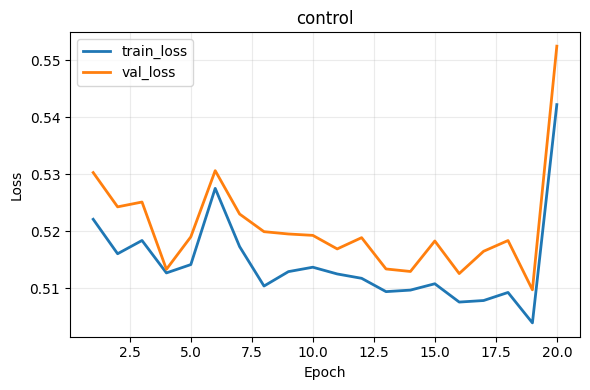

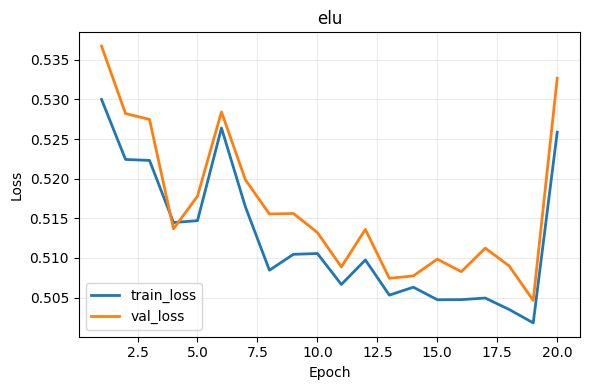

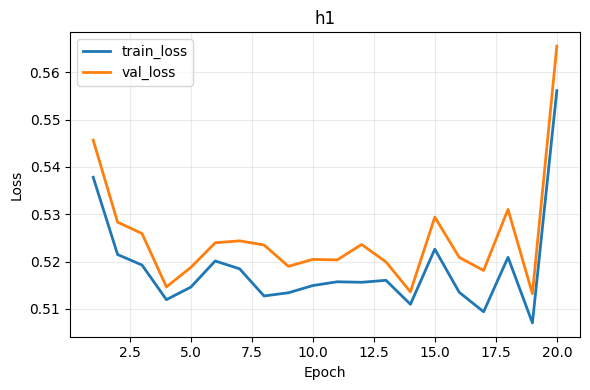

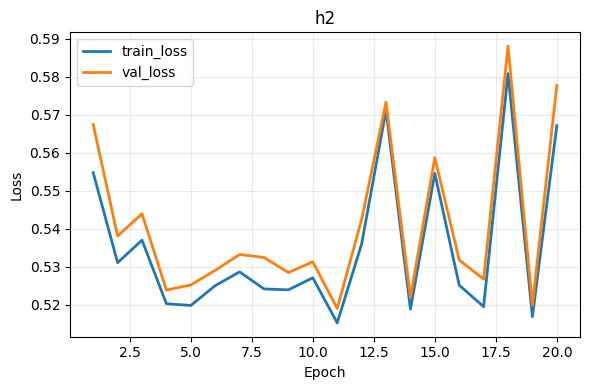

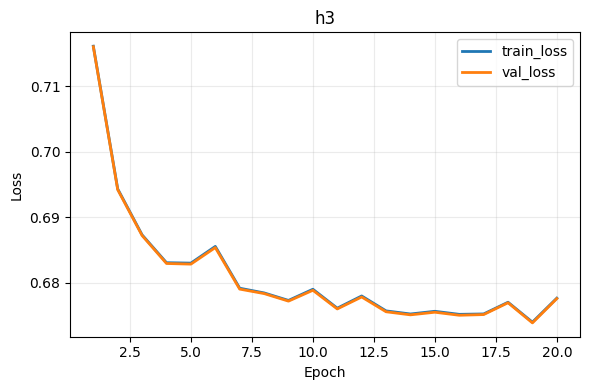

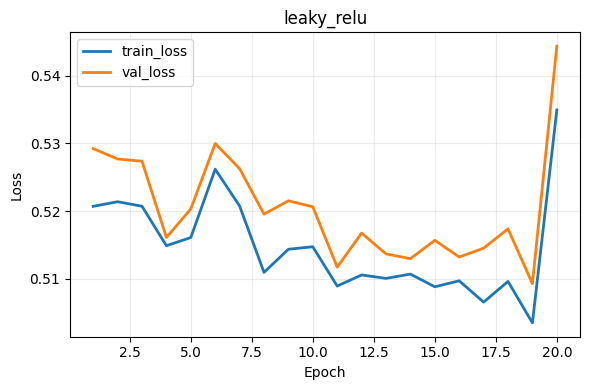

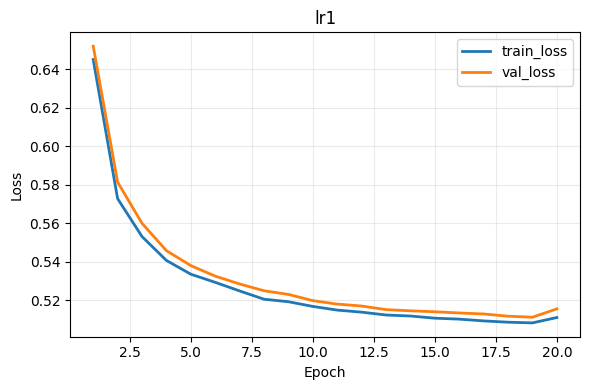

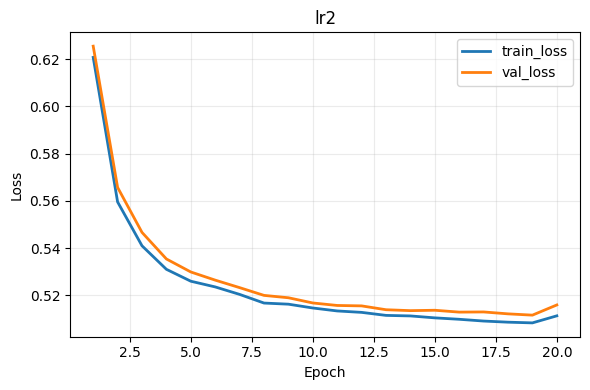

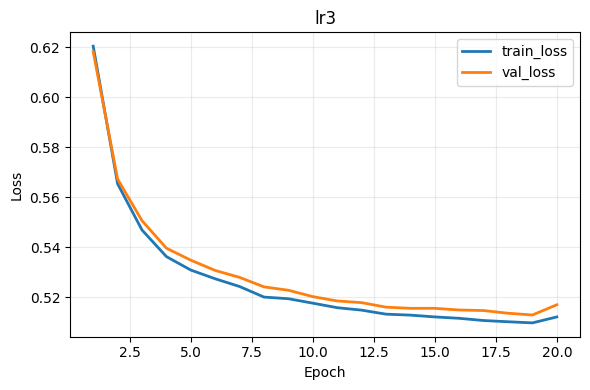

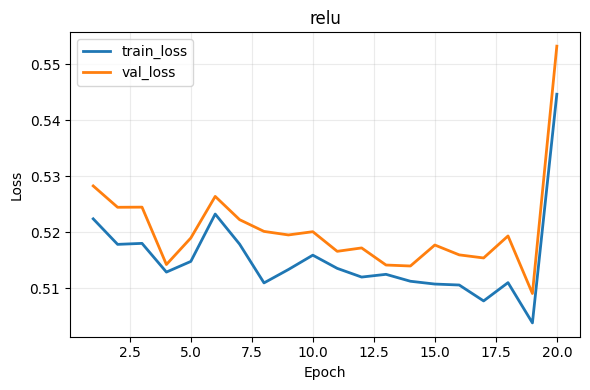

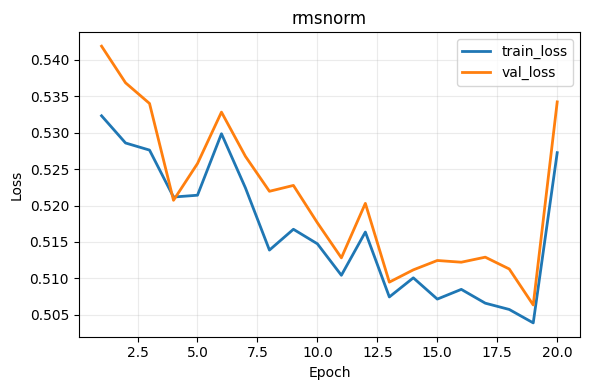

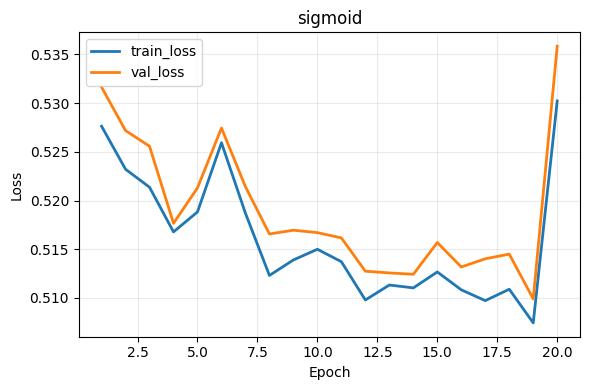

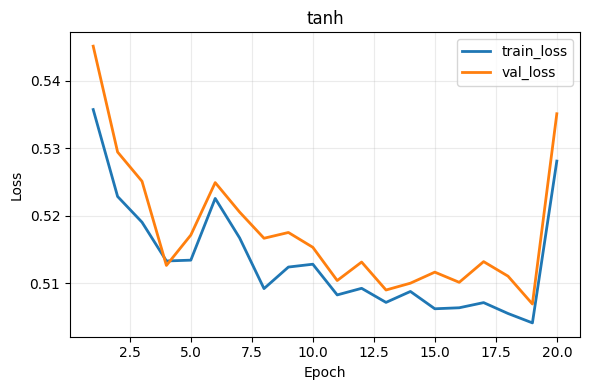

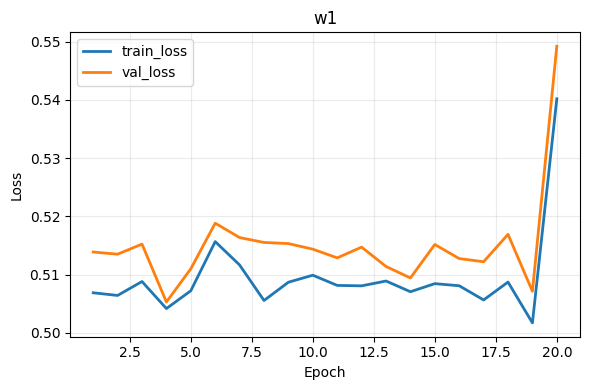

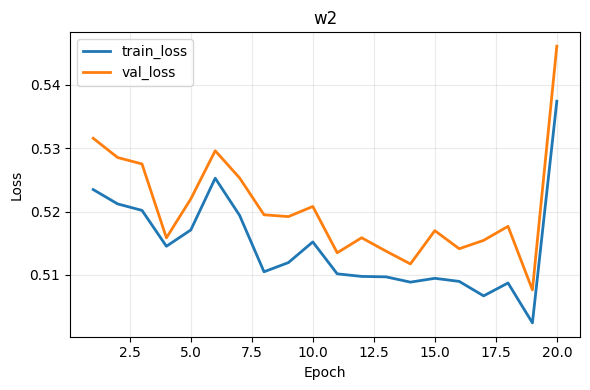

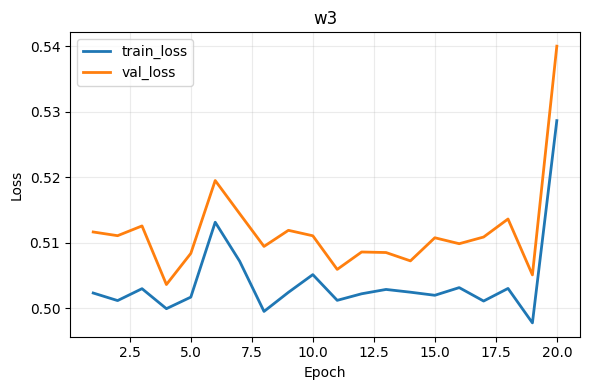

In [96]:
history_items = sorted(
    (name, value)
    for name, value in globals().items()
    if name.endswith("_history") and isinstance(value, dict)
)

if not history_items:
    raise ValueError("No *_history variables found. Run the training cells first.")

for name, history in history_items:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    train_loss = history.get("train_loss", [])
    val_loss = history.get("val_loss", [])

    if train_loss:
        train_epochs = range(1, len(train_loss) + 1)
        ax.plot(train_epochs, train_loss, label="train_loss", linewidth=2)

    if val_loss:
        val_epochs = range(1, len(val_loss) + 1)
        ax.plot(val_epochs, val_loss, label="val_loss", linewidth=2)
    else:
        ax.text(
            0.5,
            0.1,
            "val_loss unavailable",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=9,
            color="gray",
        )

    ax.set_title(name.replace("_history", ""))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()